# 微积分基础：机器学习优化的动力源泉

微积分在机器学习中主要用于：
1. **寻找损失函数的最小值**（优化问题）。
2. **理解模型参数如何影响预测结果**（灵敏度分析）。

---

## 1. 导数 (Derivative) 与 链式法则 (Chain Rule)

### 定义
导数 $f'(x)$ 描述了函数在 $x$ 处的切线斜率。对于复合函数 $y = f(g(x))$，其导数遵循**链式法则**：
$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$
这是神经网络**反向传播 (Backpropagation)** 的数学基石。

### 生动比喻
链式法则就像是**多米诺骨牌**：如果你推倒了第一块（改变了输入 $x$），它会通过中间的环节（中间变量 $u$）最终影响到最后一块（输出 $y$）。每一块倒下的速度和力度就是导数。

### 手写实现：数值微分与自动微分的思想

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 + 3*x + 2

def df_manual(x):
    """手动根据公式 (x^2+3x+2)' = 2x + 3 计算"""
    return 2*x + 3

def df_numerical(f, x, h=1e-5):
    """数值导数近似"""
    return (f(x + h) - f(x - h)) / (2 * h)

x = 2.0
print(f"x={x} 时的精确导数: {df_manual(x)}")
print(f"x={x} 时的数值导数: {df_numerical(f, x):.5f}")

x=2.0 时的精确导数: 7.0
x=2.0 时的数值导数: 7.00000


## 2. 梯度 (Gradient) 与 偏导数 (Partial Derivative)

### 定义
对于多元函数 $f(x_1, x_2, ..., x_n)$，梯度 $\nabla f$ 是一个向量，包含了所有自变量的偏导数：
$$\nabla f = \left[ \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, ..., \frac{\partial f}{\partial x_n} \right]^T$$

### 核心结论
梯度向量的方向是函数值**上升最快**的方向。因此，梯度下降法取**负梯度方向**来寻找最小值。

### 小数据案例：梯度下降手算推导
考虑损失函数：$J(x, y) = (x-2)^2 + (y-3)^2$。我们从初始点 $(x_0, y_0) = (0, 0)$ 开始，设置学习率 $\eta = 0.1$，进行一次迭代更新。

**第一步：求梯度公式**
对 $x$ 求偏导：$\frac{\partial J}{\partial x} = 2(x-2)$
对 $y$ 求偏导：$\frac{\partial J}{\partial y} = 2(y-3)$
所以梯度 $\nabla J(x, y) = [2(x-2), 2(y-3)]$

**第二步：计算初始点的梯度值**
在 $(0, 0)$ 处：
$\nabla J(0, 0) = [2(0-2), 2(0-3)] = [-4, -6]$

**第三步：执行参数更新**
根据更新公式：$\theta_{new} = \theta_{old} - \eta \cdot \nabla J$
$x_1 = x_0 - 0.1 \cdot (-4) = 0 + 0.4 = 0.4$
$y_1 = y_0 - 0.1 \cdot (-6) = 0 + 0.6 = 0.6$

经过一次迭代，参数从 $(0, 0)$ 更新到了 $(0.4, 0.6)$，离目标点 $(2, 3)$ 更近了一步。

### 可视化：动态梯度下降

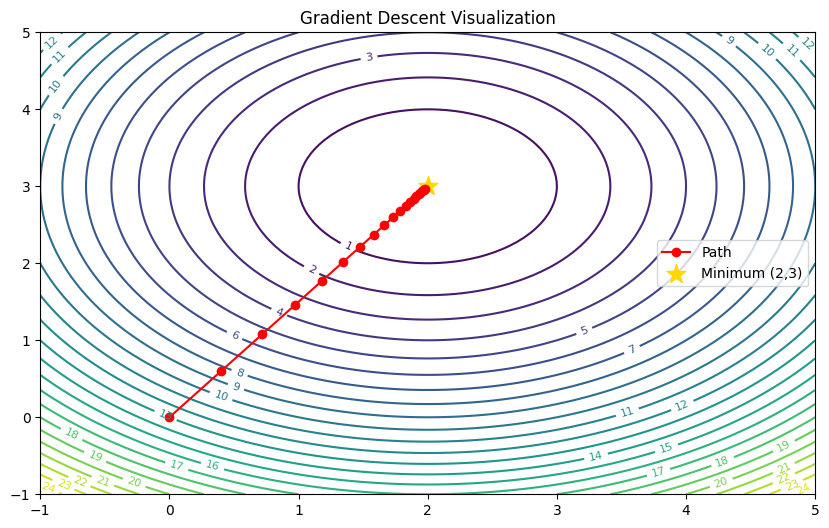

In [2]:
def func(x, y):
    return (x - 2)**2 + (y - 3)**2

def grad_func(x, y):
    return np.array([2*(x - 2), 2*(y - 3)])

def gradient_descent(start_pos, lr, n_iter):
    pos = np.array(start_pos, dtype=float)
    history = [pos.copy()]
    for _ in range(n_iter):
        grad = grad_func(pos[0], pos[1])
        pos -= lr * grad
        history.append(pos.copy())
    return np.array(history)

history = gradient_descent([0, 0], lr=0.1, n_iter=20)

# 绘图
x = np.linspace(-1, 5, 100)
y = np.linspace(-1, 5, 100)
X, Y = np.meshgrid(x, y)
Z = func(X, Y)

plt.figure(figsize=(10, 6))
cp = plt.contour(X, Y, Z, levels=30, cmap='viridis')
plt.clabel(cp, inline=True, fontsize=8)
plt.plot(history[:, 0], history[:, 1], 'ro-', label='Path')
plt.scatter(2, 3, color='gold', marker='*', s=200, label='Minimum (2,3)')
plt.title("Gradient Descent Visualization")
plt.legend()
plt.show()

## 3. 泰勒展开 (Taylor Expansion) 与 二阶优化

### 定义
泰勒公式用多项式逼近复杂函数。二阶展开形式为：
$$f(x) \approx f(a) + f'(a)(x-a) + \frac{1}{2}f''(a)(x-a)^2$$

- **一阶优化（梯度下降）**：只用到 $f'(a)$，假设函数是局部的直线。
- **二阶优化（牛顿法）**：用到 $f''(a)$（海森矩阵 Hessian），考虑了函数的**曲率**。它可以自动调整步长，在某些情况下收敛更快。

### 手写实现：海森矩阵 (Hessian Matrix) 示例
对于 $f(x, y) = x^2 + 2xy + y^2$，其海森矩阵为：
$$H = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix} = \begin{bmatrix} 2 & 2 \\ 2 & 2 \end{bmatrix}$$

### 库函数对比：使用 Scipy 进行优化

In [3]:
from scipy.optimize import minimize

def objective(params):
    x, y = params
    return (x - 2)**2 + (y - 3)**2

res = minimize(objective, [0, 0], method='BFGS') # BFGS 是一种拟牛顿法
print("Scipy 优化结果:", res.x)

Scipy 优化结果: [1.99999999 2.99999999]


### 练习与思考
1. **计算题**：求函数 $f(x, y) = x^2y + \sin(x)$ 对 $x$ 的偏导数。
2. **实验题**：尝试修改梯度下降的 `lr` 为 1.1，观察可视化路径会发生什么（震荡或发散）。
3. **进阶题**：为什么在深度学习中我们很少使用纯粹的牛顿法？（提示：海森矩阵的大小为 $N \times N$，其中 $N$ 是参数数量）。